In [1]:
import numpy as np
import matplotlib.pyplot as plt
from magnonics import *
from configs_slab.rhombitrihexagonal_slabs import *

In [2]:
hamil, lat, basis = Initialize.from_csv('configs/rhombitrihexagonal.csv')

hamil.HP_trafo(symbolic=True) # FIXME fails for symbolic = False (numeric calculation), chempot way to high

hamil.parameterize_hamil(1e-10)

1e-10

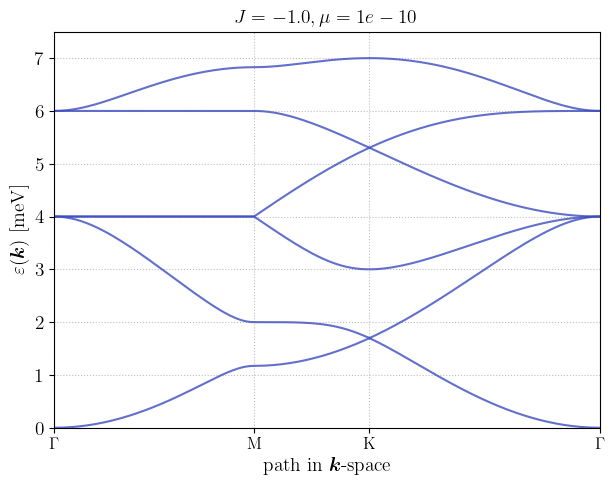

In [3]:
bz = Hexagonal(hamil, 'rhombitrihexagonal')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)
bz.save_plot(fig, overwrite=True)

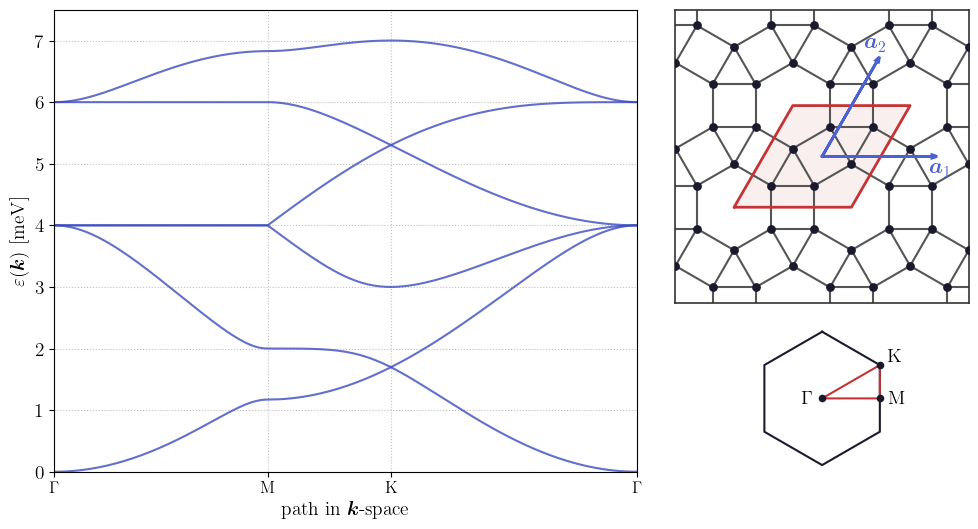

In [4]:
from numpy import sqrt

a = 1

a1 = (2 * a, 0)
a2 = (a, sqrt(3) * a)

base_pos = [
    (0.0, 0.0),
    (0.3660254, 0),
    (0.57735027, 0.21132487),
    (0.57735027, 0.57735027),
    (0.21132487, 0.57735027),
    (0, 0.3660254),
]

both = bz.plot_bs_and_lat(disp, 
                          a1, a2, base_pos, 
                          BZ_type='hexagonal',
                        #   cell_origin=(-1/5, -1/5),
                          n_shells=2,
                          view_size=2.5,
                          vect_label_offset_a1 = (0, -0.2),
                          vect_label_offset_a2 = (-0.1, 0.21),
                          figsize = (12,6),
                          wratio = [1.8, 1],
                          hratio = [2, 1],
                          wspace = 0.05,
                          hspace = 0.1,)

bz.save_plot(both, overwrite=True, filename='rhombitrihexagonal_BS_combined')

In [13]:
hamil.update_parameters({'Dz1': -0.2, 'Dz2': -0.1}, 1e-8)

Updated parameters and now using 1e-08 as chemical potential.


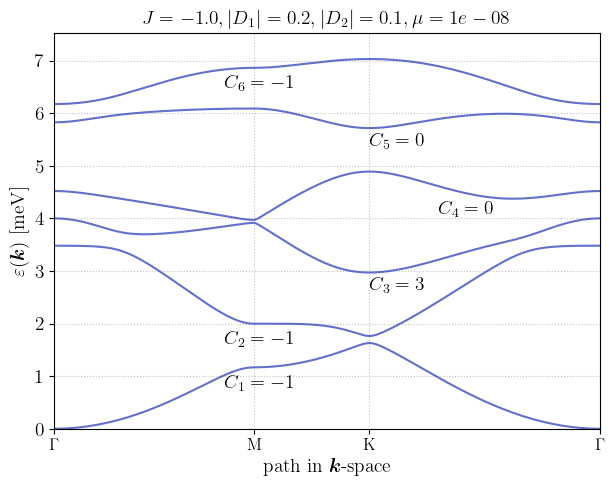

In [4]:
bz = Hexagonal(hamil, 'rhombitrihexagonal')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

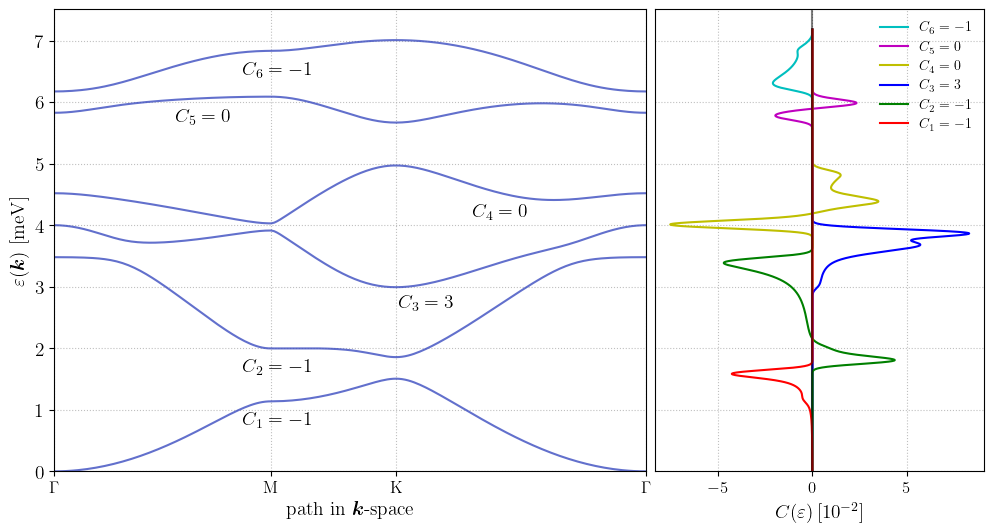

In [14]:
chern = bz.plot_bs_and_chern(disp,
                             chern_gridsize = 50,
                             sigma = 0.05,
                             points = 5000,
                             figsize = (12,6),
                             wratio = [1.8, 1],
                             wspace = 0.02,
                             decimals=0,
                             loc='upper right')

bz.save_plot(chern, overwrite=True, filename='rhombitrihexagonal_chern_1greater2')

In [15]:
hamil.update_parameters({'Dz1': -0.1, 'Dz2': -0.2}, 1e-8)

Updated parameters and now using 1e-08 as chemical potential.


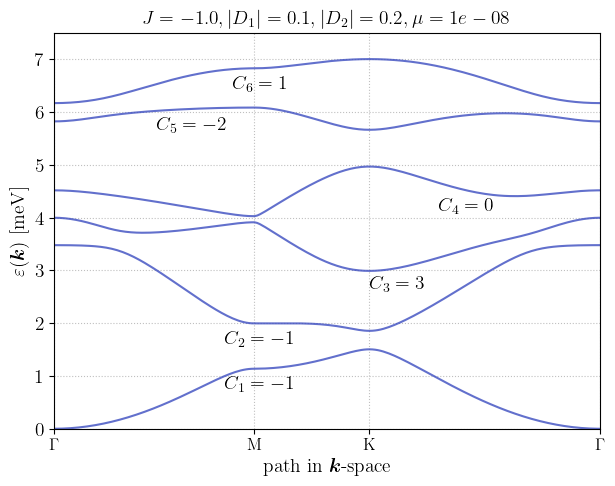

In [16]:
bz = Hexagonal(hamil, 'rhombitrihexagonal')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

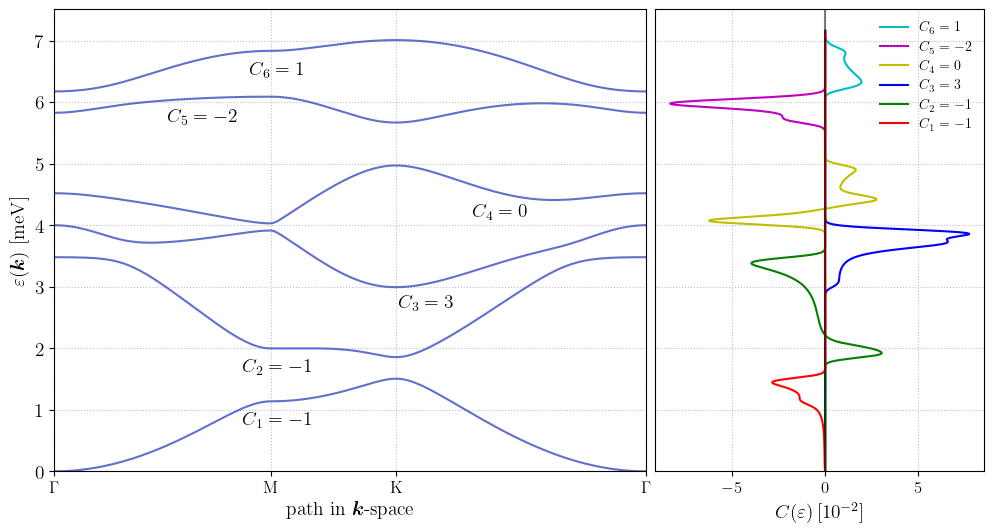

In [17]:
chern = bz.plot_bs_and_chern(disp,
                             chern_gridsize = 50,
                             sigma = 0.05,
                             points = 5000,
                             figsize = (12,6),
                             wratio = [1.8, 1],
                             wspace = 0.02,
                             decimals=0,
                             loc='upper right')

bz.save_plot(chern, overwrite=True, filename='rhombitrihexagonal_chern_2greater1')

In [9]:
hamil.update_parameters({'Dz1': -0.2, 'Dz2': -0.2}, 1e-8)

Updated parameters and now using 1e-08 as chemical potential.


In [13]:
Es, EVs = hamil.evgrid(50)

chern_numbers = np.around(hamil.chern(EVs), 2)

print(chern_numbers[:len(chern_numbers) // 2])
print(np.sum(chern_numbers[:len(chern_numbers) // 2],0))

[ 0.45 -1.45  0.    3.   -1.   -1.  ]
0.0


In [14]:
# degenerate band pairs
group1 = [0,1]
group2 = [2,3,4,5]

chern1 = hamil.non_abelian_chern(EVs, group1)
chern2 = hamil.non_abelian_chern(EVs, group2)

print(chern1, chern2, chern1+chern2, sep='\n')

-1.0
1.0
0.0


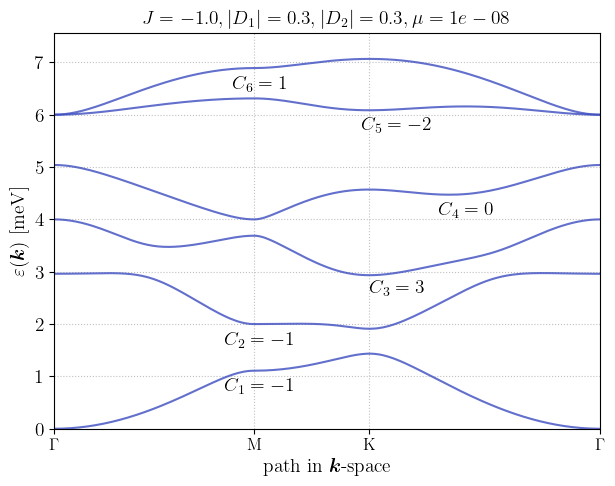

In [7]:
bz = Hexagonal(hamil, 'rhombitrihexagonal')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

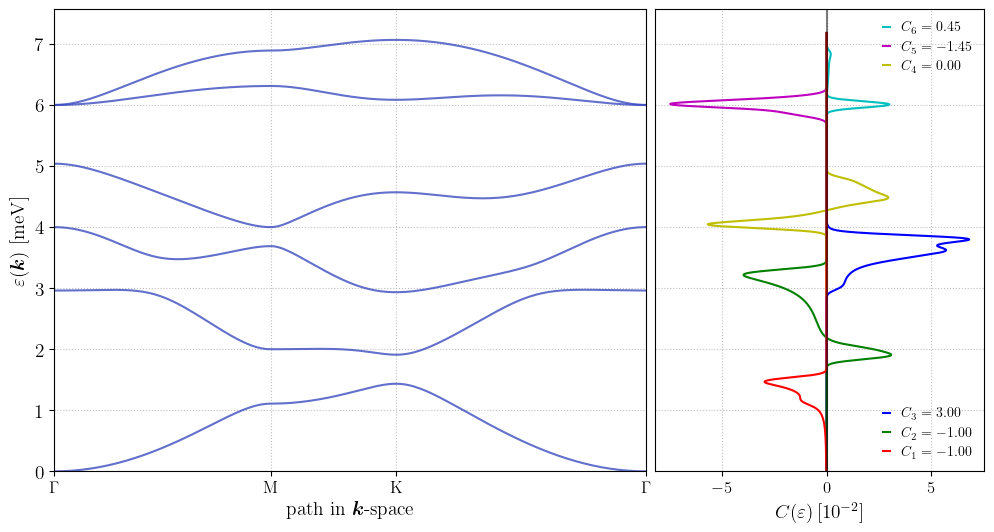

In [16]:
chern = bz.plot_bs_and_chern(disp,
                             chern_gridsize = 50,
                             sigma = 0.05,
                             points = 5000,
                             figsize = (12,6),
                             wratio = [1.8, 1],
                             wspace = 0.02,
                             decimals=2,
                             show_chern = False,
                             split = True,
                             loc2='lower right',
                             loc='upper right')

bz.save_plot(chern, overwrite=True, filename='rhombitrihexagonal_chern_equal')

Processing 6 bands with mixed shapes...


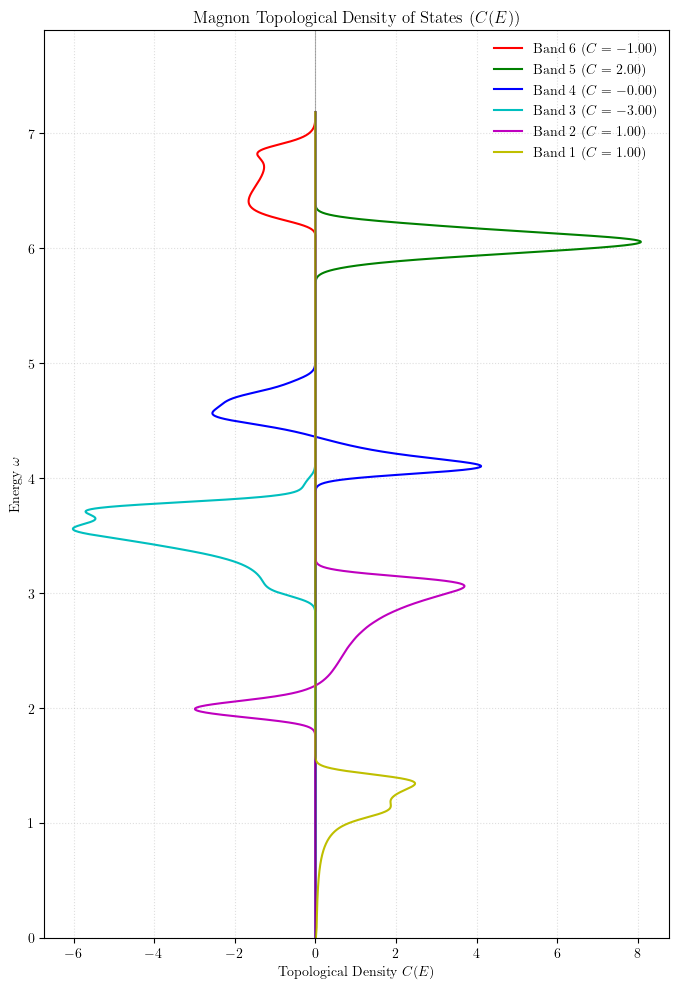

In [7]:
# params
sigma = 0.05
n_points = 5000
F_12 = - hamil.curvature_grid(EVs)

n_bands = F_12.shape[0]  # Get number of bands from the leading dim of F_12
    
# 1. Setup Energy Axis
e_min, e_max = np.min(Es) - 3*sigma, np.max(Es) + 3*sigma
energy_axis = np.linspace(e_min, e_max, n_points)

chern_density = np.zeros((n_points, n_bands))

print(f"Processing {n_bands // 2} bands with mixed shapes...")
for b in range(n_bands // 2):
    # F_12 is (Nbands, Nk1-1, Nk2-1) -> e.g., (N, 9, 9)
    # E is (Nk1, Nk2, Nbands) -> e.g., (10, 10, N)
    
    # 1. Match the shapes
    # We take the energy of the bottom-left corner of each plaquette
    nk1_flux, nk2_flux = F_12.shape[1], F_12.shape[2]
    
    energies_b = Es[:nk1_flux, :nk2_flux, b].ravel() # Slice E to (9, 9)
    flux_b = F_12[b].ravel()                        # Already (9, 9)
    
    # Now both are length 81
    diff = energy_axis[:, np.newaxis] - energies_b[np.newaxis, :]
    weights = (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (diff / sigma)**2)
    
    chern_density[:, b] = (weights @ flux_b) / (2 * np.pi)

# 4. Visualization
plt.figure(figsize=(7, 10))
total_density = np.sum(chern_density, axis=1)

colors = ['r', 'g', 'b', 'c', 'm', 'y']

for b in range(n_bands//2):
    c_val = np.sum(F_12[b]) / (2 * np.pi)
    plt.plot(chern_density[:, b], energy_axis, 
                label=f'Band {n_bands // 2 - b} ($C={c_val:.2f}$)', color=colors[b])

# plt.plot(total_density, energy_axis, 'k--', alpha=0.5, label='Total Sum')

plt.axvline(0, color='black', lw=0.8, alpha=0.3)
plt.xlabel(r"Topological Density $C(E)$")
plt.ylabel(r"Energy $\omega$")
plt.title(r"Magnon Topological Density of States ($C(E)$)")
plt.legend(frameon=False)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.ylim(ymin=0)
plt.show()

In [17]:
width1 = 30
zigzag_zigzag = build_zigzag_zigzag(width1)

Setup file saved to: c:\Users\Pascal\Desktop\magnon_code\archimedean\configs_slab\rhombitrihexagonal_zigzag_zigzag.csv


In [18]:
zigzag_zigzag, _, _ = Initialize.from_csv('configs_slab/rhombitrihexagonal_zigzag_zigzag.csv')

zigzag_zigzag.HP_trafo(symbolic=True) ;

In [19]:
zigzag_zigzag.update_parameters({'Dz1': -0.3, 'Dz2': -0.3}, 1e-2)

Updated parameters and now using 0.01 as chemical potential.


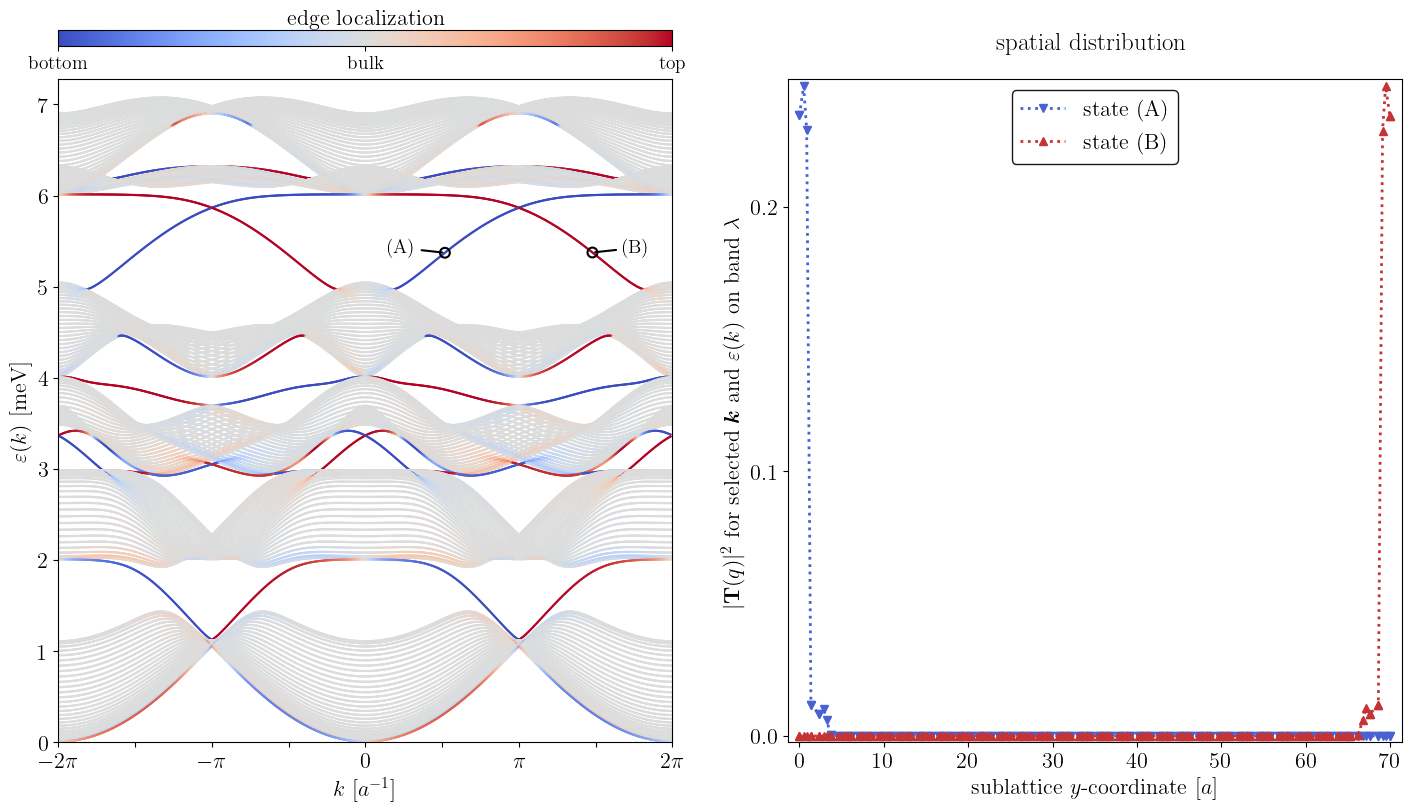

In [20]:
slab1 = Slab(zigzag_zigzag, 'rhombitrihexagonal')

state_A1 = [0.26, 5.2, '(A)', 3, 160]
state_B1 = [0.74, 5.2, '(B)', 3, 20]

fig1_bs = slab1.slab_bandplot(n_unitcells = width1, k_space = 'full', states = [state_A1, state_B1])

slab1.save_plot(fig1_bs, filename = 'rhombitrihexagonal_zigzag_zigzag_bs', format= '.png', overwrite = True)

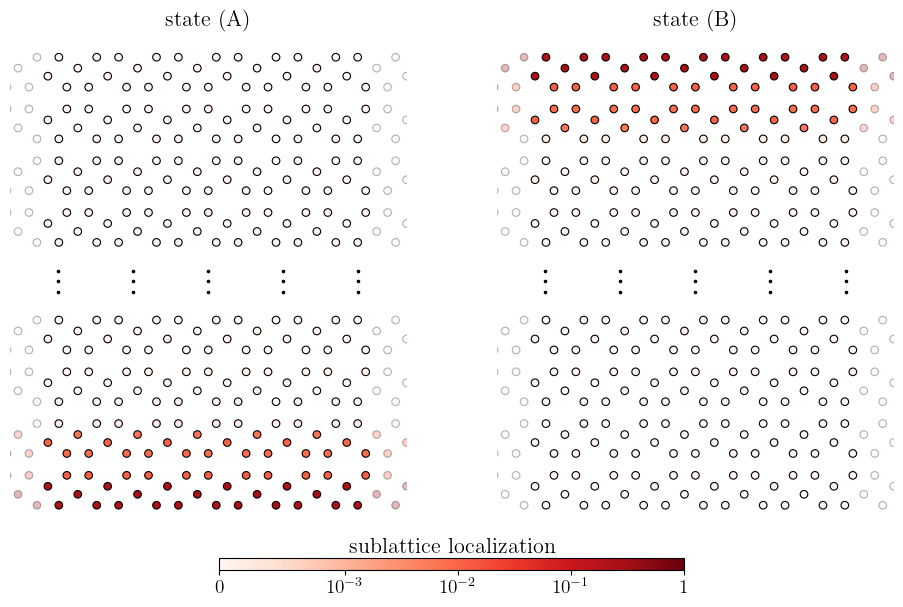

In [21]:
fig1_lat = slab1.slab_latticeplot(n_unitcells = width1, states = [state_A1, state_B1], reps = 10, gap_dot_scale = (55, 5), edge_layers = 4)

slab1.save_plot(fig1_lat, filename = 'rhombitrihexagonal_zigzag_zigzag_lat', format= '.png', overwrite = True)

In [7]:
width2 = 30
armchair_armchair = build_armchair_armchair(width2)

Setup file saved to: c:\Users\Pascal\Desktop\magnon_code\archimedean\configs_slab\rhombitrihexagonal_armchair_armchair.csv


In [8]:
armchair_armchair, _, _ = Initialize.from_csv('configs_slab/rhombitrihexagonal_armchair_armchair.csv')

armchair_armchair.HP_trafo(symbolic=True) ;

In [9]:
armchair_armchair.update_parameters({'Dz1': -0.1, 'Dz2': -0.2}, 1e-2)

Updated parameters and now using 0.01 as chemical potential.


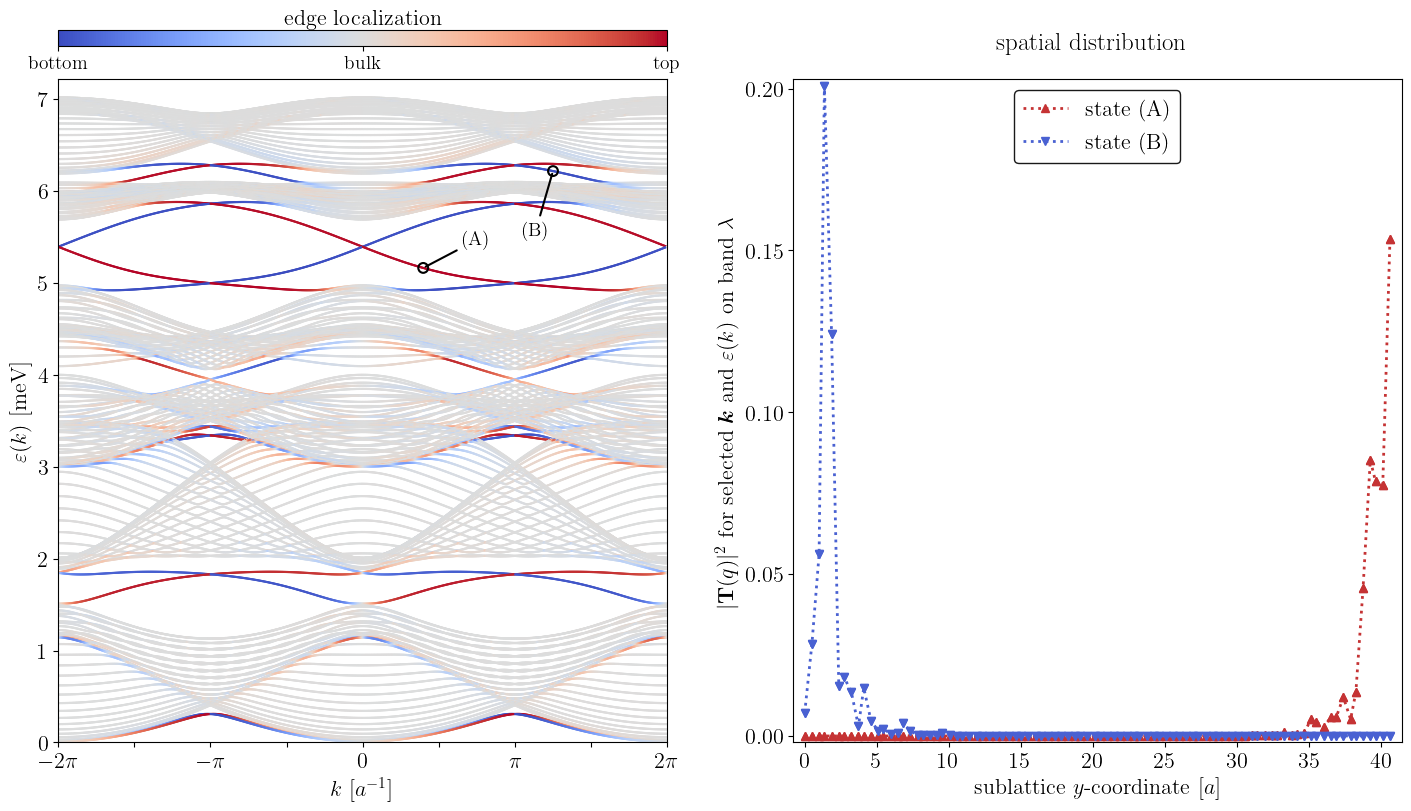

In [10]:
slab2 = Slab(armchair_armchair, 'rhombitrihexagonal')

state_A2 = [0.2, 5.2, '(A)', 7, 60]
state_B2 = [0.625, 6.2, '(B)', 13, -95]

fig2_bs = slab2.slab_bandplot(n_unitcells = width2, k_space = 'full', states = [state_A2, state_B2])

slab2.save_plot(fig2_bs, filename = 'rhombitrihexagonal_armchair_armchair_bs', format= '.png', overwrite = True)

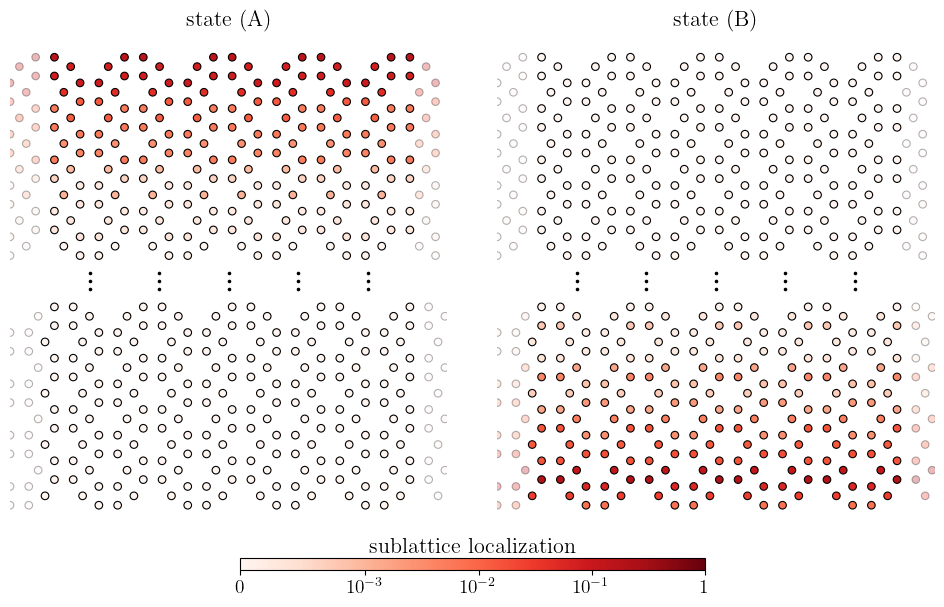

In [14]:
fig2_lat = slab2.slab_latticeplot(n_unitcells = width2, states = [state_A2, state_B2], reps = 10, gap_dot_scale = (120, 5), gap_pad= 2, edge_layers = 8)

slab2.save_plot(fig2_lat, filename = 'rhombitrihexagonal_armchair_armchair_lat', format= '.png', overwrite = True)